# Day 11 In-class Assignment

---


### <p style="text-align: right;"> &#9989; Put your name here </p>

#### <p style="text-align: right;"> &#9989; Put your group member names here.</p>

## How *high* can a cow get?

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/cattle_hemp_01.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 55%" alt="Two images. One depicts cannabis leaves. The other one shows a cow staring at the camera.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://www.indiatimes.com/technology/science-and-future/cows-that-were-fed-hemp-instead-of-regular-fodder-produced-cannabis-infused-milk-585147.html" target="_blank">India Times</a></p>

### Learning goals for today's assignment

- Load in data and clean Pandas dataframes
- Learn different ways to index Pandas dataframes
- Analyze different cannabinoid concentration values
- Practice using online research to learn new programming skills

### Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the Notebook. The assignment is due at the end of class.

---

## Background: Is hemp a viable cattlefeed?

As more states legalize the recreational use of cannabis, cannabis production has grown considerably. However, after you process the cannabis plants for human products, you are left behind with byproducts that usually just go to waste. A considerable byproduct is hemp waste. What if instead of discarding the hemp leftovers, we give them to cattle? That way, the "waste" now is transformed (eventually) in beef and other human-consumption products.

But, is it safe to eat hemp-fed cattle in the first place? How much &Delta;9-THC (the main psychoactive component of cannabis) is actually concentrated in the beef?

You can read more details from the recent paper:

> Fritz, B.R., Kleinhenz, M.D., Magnin, G. *et al.* (2025) [Tissue residue depletion of cannabinoids in cattle administered industrial hemp inflorescence.](https://doi.org/10.1038/s41598-025-26448-5) *Scientific Reports* **15**(42337)

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/fritz_etal_2025_f1.png" style="display:block; margin-left: auto; margin-right: auto; width: 85%" alt="Scatterplots of cannabinoid concentrations in liver, kidney, muscle and adipose tissue of cattle administered industrial hemp inflorescence.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1038/s41598-025-26448-5" target="_blank">Fritz et al (2025)</a></p>


&#9989;&nbsp; **Question:**

- Only looking at Figure D: What information can you extract from the graph above?
- Are the colors consistent across the rest of figures? Is it easy to keep track of &Delta;9-THC across plots?

<font size=6 color="#009600">&#9998;</font> *Put your response here*

---

# 1. Practice calculating statistics using Python

Recall from the Day 10 in-class assignment that we can use descriptive statistics such as mean, median, and standard deviation to get a sense for how data are distributed. To build on your previous work and learn more about how we can use descriptive statistics, we are going to explore them *visually.*

### 1.1 Visual descriptive statistics

First, let's cover how to visualize the distribution of a one-dimensional data set. We begin with a random distribution of numbers from a random number generator in the NumPy library.

In [1]:
# You might not be familiar this with random number generator, that's OK,
# This is one of _many_ that are available in NumPy.
import numpy as np

# Random number generator
# We set a fixed seed (it can be ANY number) so that results are reproducible

rng = np.random.default_rng(seed = 42)
random_distribution = rng.wald(200,500,size=1000)

This is an array holding 1000 random numbers, generated from a statistical distribution called the "[Wald distribution](https://en.wikipedia.org/wiki/Inverse_Gaussian_distribution)" (or "inverse gaussian distribution").

Let's look at the first 10 numbers. **Take special notice of how we are "slicing" the array to get just a subset of the values using "`:`"!**

In [2]:
# Run this cell!
random_distribution[0:10]

array([164.99156752, 320.08886178, 642.24116457, 216.8376094 ,
       197.88606416, 346.39073372, 208.52851874, 148.96406809,
       158.47933792, 115.54323376])

And now let's make a plot all of the elements:

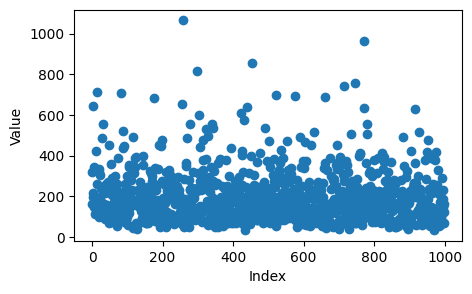

In [3]:
# Run this cell!
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(random_distribution,'o')
ax.set_xlabel('Index')
ax.set_ylabel('Value');

What are some other ways we can analyze and visualize this data?  One visualization is a box plot, which shows where the ***quartiles*** of the data set are, as well as **outliers**.

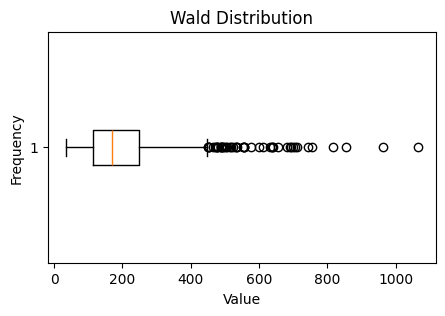

In [4]:
# Run this cell!
fig, ax = plt.subplots(figsize=(5,3))
ax.boxplot(random_distribution, vert=False)
ax.set_ylabel("Frequency")
ax.set_xlabel("Value")
ax.set_title("Wald Distribution");

Another visualization is a **histogram**, which splits the data set into a bunch of equally sized intervals, and then graphs the number of data points that fall into each interval. The higher the bar on a histogram, the more data points in that interval. Thought of another way, a histogram shows you the "count" or "frequency" of values falling into a specific bin on the x-axis.

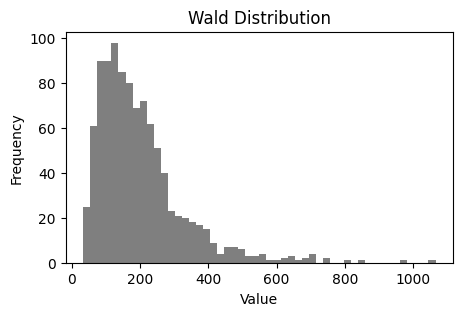

In [5]:
# Run this cell!
fig, ax = plt.subplots(figsize=(5,3))
ax.hist(random_distribution, bins=50, color="k", alpha=0.5) #what's the alpha argument doing?
ax.set_ylabel("Frequency")
ax.set_xlabel("Value")
ax.set_title("Wald Distribution");

&#9989;&nbsp; **Question 1**

Compare the representations above

- What are the similarities between how the boxplot represents the data set versus the histogram?
- What does the boxplot do a better job of showing?
- What does the histogram do a better job of showing?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### 1.2 Compute and Compare

Now lets actually compute the mean and median and visualize them on the distribution graph.

&#9989;&nbsp; **Task 2**

- Add **two vertical lines** with different colors where the **mean** and **median** are using [Matplotlib's `ax.axvline()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvline.html) function.
- Make sure you label your lines and include a legend.

This `.axvline` might be new to you, so make sure you understand how it works!

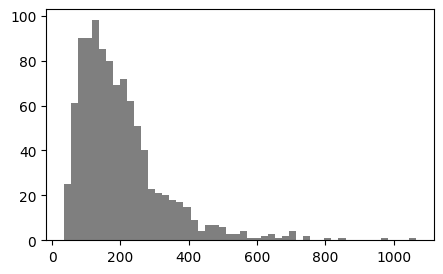

In [6]:
fig, ax = plt.subplots(figsize=(5,3))
ax.hist(random_distribution,bins=50,color="k",alpha=0.5);
# Add your additional plotting commands here

# The following line is provided to help get you started, you need to decide what to use for the "x" argument
#ax.axvline(x=?,linewidth=2, color='r',label = "Median")


&#9989;&nbsp; **Question 3**

- Which is larger for this data set, mean or median? Explain why you think that is.

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

---

# 2. Loading in and cleaning happy cow data

The next part we will focus on transforming and manipulating a dataset using Pandas. As data scientist/computational professional in training, one of the goals we want you to accomplish is to be comfortable searching through online resources to try and solve problems.

There are far too many functions and concepts in programming to remember everything so in practice it's essential to utilize package documentation, stack overflow, etc. Some of the questions you will see below will ask you to use or look for a function you've never used before to get you to practice [Duckduckgoing](https://duckduckgo.com/) questions that help you accomplish your task.

## What data are we working with?

In Canvas, you should find four CSVs corresponding to four different cattle tissues: liver, kidney, muscle, adipose.
- Rows represent the average concentration detected for a specific cannabinoid (in ng/g)
- Columns represent number of days since the last cannabis dosage given to the cattle

The data corresponds (mostly) to Table 2 from [Fritz et al (2025)](https://doi.org/10.1038/s41598-025-26448-5).

### 2.0 A little extra work goes a long way

Let's start with the right foot

&#9989;&nbsp; **Task 3**

Below is already a string variable `tissue` defined for you. It is a reference to the adipose tissue.

- *With the `tissue` variable*, define a new string variable `filename` so that it equals `adipose_mean.csv`
- Remember that you can concatenate strings with `+`

In [7]:
# Finish the one line of code

tissue = 'adipose'
#filename = 

### 2.1 Cleaning data before analyzing data.

First, we're going to load in the `.csv` dataset into a Pandas Dataframe and explore the original structure of the data and think about if it could be formatted in a more useful way.

Make sure you import the Pandas module before moving on!

In [8]:
# put your Pandas import command here


&#9989;&nbsp; **Task 4**

- Load in the `adipose_mean.csv` file using `pd.read_csv()`.
- With `.shape`, print the DataFrame's number of rows and columns. You should have 21 rows and 6 columns of data.
- Display the first few lines using `.head()`.

Use `tconc` (tissue concentration) as the variable name for storing your dataframe as indicated in the code cell below.

In [9]:
# Load in adipose_mean.csv
#tconc = # Finish this line to load in the data!

&#9989;&nbsp; **Question 5:**

You probably notice a bunch of "NaN"s in the loaded dataframe. What happens if you open `adipose_mean.csv` in Excel? Can you guess why Pandas report some "NaN" values?

<font size=6 color="#009600">&#9998;</font> *Put your response here*

As a first step to cleaning a data set, it can be helpful to get rid of rows that have a lot of "NaN" values. NaN means "Not a Number," and it is a value that sometimes takes the place of a blank entry, a non-applicable entry, a not-available value, etc. For instance, 8-THC was never detected in the adipose tissue, so its concentration is reported as "NaN".

It does not make sense to analyze cannabinoids that does not exist, so we are going to "drop" them from the data set, using then handy pandas function `.dropna`. *Note*: depending on the context, sometimes keeping "NaN"s around is useful.

**Note**: sometimes when you use Pandas function is modifies your dataframe directly, but other times it generates a *new* dataframe based on the old one. When the function **returns** a new dataframe, we need to make sure we store that result in a variable. **Look carefully at the code below to see how this is being done**.

In [10]:
tconc = tconc.dropna(axis="rows", how="any") # drop rows with NaNs, like 8-THC
print('We now have',tconc.shape[0],'rows and',tconc.shape[1],'columns.')
tconc.head()

NameError: name 'tconc' is not defined

**Note that the `.dropna` function was accessed from the dataframe itself (`tconc.dropna()`).**

These functions are included with each dataframe object. We've already seen this with functions like `.describe()`, and even with numpy array functions like `my_array.mean()`.  Many of the functions you'll be using today are included with the dataframe objects.

You can browse through these built-in functions by typing the name of a dataframe followed by `.` and then hitting the `Tab` key.  Try it out below!

In [11]:
# uncomment the line below, then go to the end of the line and hit tab
#tconc.

If you want to learn more about something, select it (or type it out), add a question mark (`?`) and then run the cell. **Ask an instructor for help if you can't get the `?` mark trick to work!**
___

### 2.2 Making the dataset easier to explore

Typically when we are looking at data over time we represent each time step as a row rather than a column. Switching the rows and columns is an operation known as "Transposing" and [Pandas has a function](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transpose.html) that does that!

**IMPORTANT:** When you use Pandas functions on dataframes, most functions will **not** modify the original dataframe. This means that the results are not saved unless you save them to a variable!

Let's transpose the dataset to get years as rows instead of columns.

Example of Transposing:

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/pandas_transpose_dataframe.png" style="display:block; margin-left: auto; margin-right: auto; width: 60%" alt="Diagram of an original and a transposed dataframe">


&#9989;&nbsp; **Task 6**

- Transpose the data to flip the orientation of the rows and columns.

In [12]:
# Transpose the dataframe here and check to see if it worked
# MAKE SURE YOU SAVE YOUR TRANSPOSED DATAFRAME AS A VARIABLE
# Your transposed data frame should have 6 rows and 4 columns

One of the benefits of Pandas Dataframe is being able to index a column by name rather than a number. `CBD` is a much more descriptive column name than `11`.

&#9989;&nbsp; **Task 7**

- Modify the dataframe so that each cannabinoid is used as the column headers by assigning the first row of the dataframe to be the column headers.

Think back to the Pre-Class Assignment. What information are you looking to retrieve? What tools do you have to access this information? You may want to use `.iloc` to do this. If done correctly, you then should be able to index a column out of our dataframe using `adipose['CBD']`, for example. Make sure to test this out!

In [13]:
# Change the column headers to be the country names here.
# You still have 6 rows and 4 columns


This is looking pretty good! Of course, now we have a redundant "Cannabinoid" row.

&#9989;&nbsp; **Task 8**

- Remove this cannabinoid row.
- There's more than one way to do this.
- The best option is to use the `tconc.drop` function. Figure out how it works with `tconc.drop?` or duckduckgo the official documentation.

In [14]:
# Try to remove the rows that don't represent years here
# You dropped one row: so now you have 5 rows and 4 columns


Now our dataset should be in an easier format. The next step is to examine the structure of our data.

&#9989;&nbsp; **Task 9**

Review the following code and comment what each line is doing.

In [15]:
print(tconc.index) #comment here


print(type(tconc.index[0])) #comment here

NameError: name 'tconc' is not defined

We can see the index column is made up of strings representing number of days (after last cannabis dosage), which isn't ideal!

The code below will change the data type from strings to integers. This will be helpful for when we begin plotting because when you try to plot strings as numbers it doesn't usually work out very well!

In [16]:
tconc.index = tconc.index.astype(int)
tconc.index

NameError: name 'tconc' is not defined

### 2.2 Exploring the Data

&#9989;&nbsp; **Task 10**

- Pick cannabinoids `'9-THC'` and `'CBD'` and print their concentration 3 days after last dosage using `.loc` and the column name.
- Look back at the dataset and think about what information we are looking to retrieve.

What information is stored in our columns? What information is stored in our rows? 

In [17]:
# Put your code here


&#9989;&nbsp; **Task 11**

- Plot those two cannabinoid concentrations for the days in the dataset
- Make sure to have proper labels and legends.
- *Hint*: Instead of explicitly writing "Adipose tissue" as the title, use the `tissue` variable instead.
    - *Hint 2*: `tissue.capitalize()` will capitalize the string
    - `.capitalize()` is one of the many functions available *for strings* (the same way we've been discussing functions for dataframes).

In [18]:
# Put your plotting commands here


&#9989;&nbsp; **Question 12**

- Is this a good way visual comparison for the two cannabinoids?
- If one cannabinoid has a much larger concentration than the other, what would be a better way to normalize or compare the data?

This might involve doing some sort of calculation or visualizing the data differently. How is it done by Fritz et al (2025)?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

### 2.3 Exploring the log-linear plot

Following Fritz et al (2025), you can change the scaling of an axis for a matplotlib plot [using `ax.set_yscale('log', base=10)`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_yscale.html). Or, you can try using [the `ax.semilogy()` function](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.semilogy.html).

Notice that this way we change the plot, not the values like we were doing in the allometry assignments.

&#9989;&nbsp; **Task 13**

- Remake the previous plot but now with a log scale
- Does it facilitate a better comparison?

In [19]:
# Try making a "semilogy" plot here or try use the `ax.set_yscale('log', base=10)` function to modify your plot


&#9989;&nbsp; **Question 14**

- Do you find this to be a better way to visualize the data, yes or no? Explain your reasoning!
- Does it resemble the plots from Fritz et al?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

---

## 3. Looking at the rest of the tissues [TIME PERMITTING]

Remember that we defined `tissue` as "adipose" to load&mdash;and then explore and analyze&mdash;the cannabinoid concetration in adipose tissue for cattle. The rest of variables that we defined, are "neutral" in a sense. We did this on purpose because we do not want to make our code just for adipose tissue. We have more data to explore!

(Yes, we could have named the variable `adipose` instead of `tissue`, but that would have made our code less readable. Remember In-Class 04.)

&#9989;&nbsp; **Task 15**

- Make a copy of this notebook
    - There are many ways to do this.
    - My personal go-to is to use the Jupyter file explorer (what you launch in the first place), select the Notebook, and then click "Duplicate" on the top menu.

**Talk to an instructor if you are having issues with the duplication**.

**Read the following before you switch your attention to the copy**.

Now that you have a copy, open it.

- Go straight to subsection (2.0) and now change `tissue` for either "liver" or "kidney"
- The re-run all the code you wrote for Section 2. You may need to add `import matplotlib.pyplot as plt` at the begining.
- Did you need to make any additional changes for new tissue?
- What would you do if you had to analyze 25+ tissue files?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

&#9989;&nbsp; **Task 16**

- With the same copy, repeat Task 15 but now look at the muscle tissue
- Did you run into issues this time?
- What do you think are possible causes of this errors?
- If you had more time, how would you fix the issues?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

**Sneak peek:** We will look at some of these issues and fix them in future assignments. Stay tuned.

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "In-class assignments" folder, find the appropriate submission folder link, and upload it there.

See you in class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri